In [1]:
##

In [2]:
#import Libraries
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [3]:
# ── 1. Descriptive Statistics ─────────────────────────────────────
print("=" * 45)
print("   DESCRIPTIVE STATISTICS")
print("=" * 45)

data = [23, 45, 67, 12, 89, 34, 56, 78, 45, 23, 67, 90, 34, 56, 45]

print(f"Mean               : {np.mean(data):.2f}")
print(f"Median             : {np.median(data):.2f}")
print(f"Mode               : {stats.mode(data, keepdims=True).mode[0]}")
print(f"Variance           : {np.var(data):.2f}")
print(f"Standard Deviation : {np.std(data):.2f}")
print(f"Min                : {np.min(data)}")
print(f"Max                : {np.max(data)}")
print(f"Range              : {np.max(data) - np.min(data)}")



   DESCRIPTIVE STATISTICS
Mean               : 50.93
Median             : 45.00
Mode               : 45
Variance           : 535.40
Standard Deviation : 23.14
Min                : 12
Max                : 90
Range              : 78


In [5]:
print("=" * 45)
print("   Interquantile range")
print("=" * 45)
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
print(f"Q1                 : {q1}")
print(f"Q3                 : {q3}")
print(f"IQR                : {iqr}")
print(f"Outlier boundaries : < {q1 - 1.5*iqr:.1f}  or  > {q3 + 1.5*iqr:.1f}")

   Interquantile range
Q1                 : 34.0
Q3                 : 67.0
IQR                : 33.0
Outlier boundaries : < -15.5  or  > 116.5


In [6]:
# ── 2. Hypothesis Testing ─────────────────────────────────────────
print("\n" + "=" * 45)
print("   HYPOTHESIS TESTING (Two-Sample t-test)")
print("=" * 45)

model_a = [0.82, 0.85, 0.83, 0.86, 0.84, 0.85, 0.83, 0.82, 0.86, 0.84]
model_b = [0.87, 0.89, 0.88, 0.90, 0.87, 0.91, 0.88, 0.89, 0.87, 0.90]

t_stat, p_value = stats.ttest_ind(model_a, model_b)
print(f"Model A mean accuracy : {np.mean(model_a):.4f}")
print(f"Model B mean accuracy : {np.mean(model_b):.4f}")
print(f"Difference            : {np.mean(model_b) - np.mean(model_a):.4f}")
print(f"t-statistic           : {t_stat:.4f}")
print(f"p-value               : {p_value:.6f}")
if p_value < 0.05:
    print("Conclusion            : Model B is significantly better ✓")
else:
    print("Conclusion            : No significant difference ✗")



   HYPOTHESIS TESTING (Two-Sample t-test)
Model A mean accuracy : 0.8400
Model B mean accuracy : 0.8860
Difference            : 0.0460
t-statistic           : -7.0423
p-value               : 0.000001
Conclusion            : Model B is significantly better ✓


In [7]:
# ── 3. Confidence Interval ────────────────────────────────────────
print("\n" + "=" * 45)
print("   CONFIDENCE INTERVAL (95%)")
print("=" * 45)

n   = len(model_b)
ci  = stats.t.interval(0.95, df=n-1,
                       loc=np.mean(model_b),
                       scale=stats.sem(model_b))
print(f"Sample mean    : {np.mean(model_b):.4f}")
print(f"95% CI         : [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"Interpretation : We are 95% confident true accuracy is "
      f"between {ci[0]:.1%} and {ci[1]:.1%}")



   CONFIDENCE INTERVAL (95%)
Sample mean    : 0.8860
95% CI         : [0.8758, 0.8962]
Interpretation : We are 95% confident true accuracy is between 87.6% and 89.6%


In [8]:
# ── 4. Correlation ────────────────────────────────────────────────
print("\n" + "=" * 45)
print("   CORRELATION")
print("=" * 45)

experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
salary     = np.array([6, 8, 10, 13, 15, 18, 22, 26, 30, 35])

r, p_corr = stats.pearsonr(experience, salary)
print(f"Pearson r      : {r:.4f}")
print(f"p-value        : {p_corr:.6f}")
if r > 0.7:
    print("Interpretation : Strong positive correlation ✓")
elif r > 0.3:
    print("Interpretation : Moderate positive correlation")
else:
    print("Interpretation : Weak or no linear correlation")




   CORRELATION
Pearson r      : 0.9889
p-value        : 0.000000
Interpretation : Strong positive correlation ✓


In [9]:
# ── 5. Linear Regression ─────────────────────────────────────────
print("\n" + "=" * 45)
print("   LINEAR REGRESSION")
print("=" * 45)

slope, intercept, r_value, p_val, std_err = stats.linregress(experience, salary)
print(f"Slope (m)      : {slope:.4f}  [₹{slope:.2f}L increase per year of experience]")
print(f"Intercept (c)  : {intercept:.4f}")
print(f"R² Score       : {r_value**2:.4f}  [model explains {r_value**2*100:.1f}% of variance]")
print(f"Equation       : Salary = {slope:.2f} × Experience + {intercept:.2f}")
for yrs in [11, 12, 15]:
    pred = slope * yrs + intercept
    print(f"Prediction ({yrs} years experience) : ₹{pred:.2f}L")



   LINEAR REGRESSION
Slope (m)      : 3.1818  [₹3.18L increase per year of experience]
Intercept (c)  : 0.8000
R² Score       : 0.9779  [model explains 97.8% of variance]
Equation       : Salary = 3.18 × Experience + 0.80
Prediction (11 years experience) : ₹35.80L
Prediction (12 years experience) : ₹38.98L
Prediction (15 years experience) : ₹48.53L


C:\Users\nidhi\AppData\Local\Temp\ipykernel_12476\3334964768.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([model_a, model_b], labels=['Model A', 'Model B'],


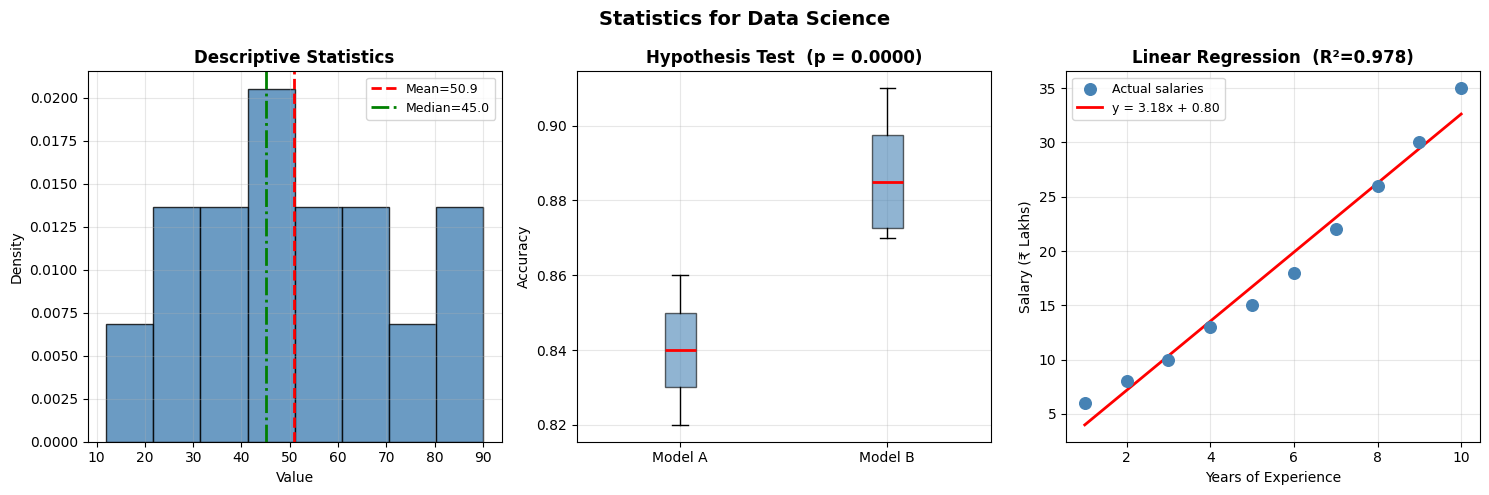


Plot saved as statistics_demo.png


In [11]:
# ── 6. Visualise ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Statistics for Data Science', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(data, bins=8, color='steelblue', edgecolor='black',
             alpha=0.8, density=True)
axes[0].axvline(np.mean(data), color='red', linestyle='--',
                linewidth=2, label=f'Mean={np.mean(data):.1f}')
axes[0].axvline(np.median(data), color='green', linestyle='-.',
                linewidth=2, label=f'Median={np.median(data):.1f}')
axes[0].set_title('Descriptive Statistics', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Box plot — hypothesis test
axes[1].boxplot([model_a, model_b], labels=['Model A', 'Model B'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'Hypothesis Test  (p = {p_value:.4f})', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

# Regression
y_pred = slope * experience + intercept
axes[2].scatter(experience, salary, color='steelblue', s=70, zorder=5,
                label='Actual salaries')
axes[2].plot(experience, y_pred, 'r-', linewidth=2,
             label=f'y = {slope:.2f}x + {intercept:.2f}')
axes[2].set_title(f'Linear Regression  (R²={r_value**2:.3f})', fontweight='bold')
axes[2].set_xlabel('Years of Experience')
axes[2].set_ylabel('Salary (₹ Lakhs)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('statistics_demo.png', dpi=150)
plt.show()
print("\nPlot saved as statistics_demo.png")


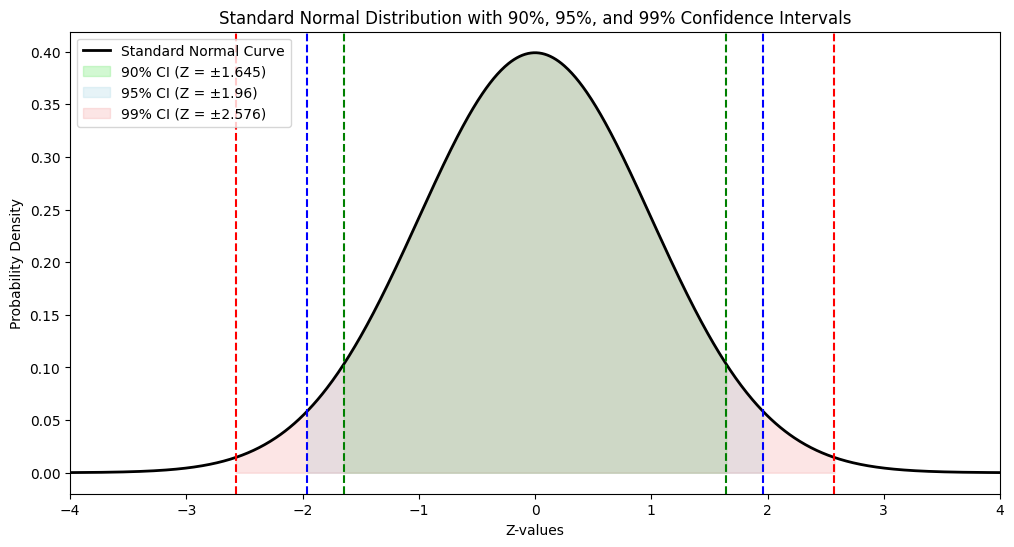

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Plotting settings
mu = 0
sigma = 1
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, color='black', linewidth=2, label='Standard Normal Curve')

# ----------------------------
# 90% Confidence Interval (Z = ±1.645)
# ----------------------------
z90 = 1.645
x_fill90 = np.linspace(-z90, z90, 500)
y_fill90 = stats.norm.pdf(x_fill90, mu, sigma)
ax.fill_between(x_fill90, y_fill90, color='lightgreen', alpha=0.4,
                label='90% CI (Z = ±1.645)')
ax.axvline(-z90, color='green', linestyle='--')
ax.axvline(z90, color='green', linestyle='--')

# ----------------------------
# 95% Confidence Interval (Z = ±1.96)
# ----------------------------
z95 = 1.96
x_fill95 = np.linspace(-z95, z95, 500)
y_fill95 = stats.norm.pdf(x_fill95, mu, sigma)
ax.fill_between(x_fill95, y_fill95, color='lightblue', alpha=0.3,
                label='95% CI (Z = ±1.96)')
ax.axvline(-z95, color='blue', linestyle='--')
ax.axvline(z95, color='blue', linestyle='--')

# ----------------------------
# 99% Confidence Interval (Z = ±2.576)
# ----------------------------
z99 = 2.576
x_fill99 = np.linspace(-z99, z99, 500)
y_fill99 = stats.norm.pdf(x_fill99, mu, sigma)
ax.fill_between(x_fill99, y_fill99, color='lightcoral', alpha=0.2,
                label='99% CI (Z = ±2.576)')
ax.axvline(-z99, color='red', linestyle='--')
ax.axvline(z99, color='red', linestyle='--')

# Formatting
ax.set_title('Standard Normal Distribution with 90%, 95%, and 99% Confidence Intervals')
ax.set_xlabel('Z-values')
ax.set_ylabel('Probability Density')
ax.set_xlim(-4, 4)
ax.legend(loc='upper left')

plt.show()